[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/10_RAG/notebooks/09_ragas_evaluation.ipynb)

# Evaluating RAG with RAGAS

**Notebook 09 · Phase 3 (Evaluation)** · Stack: `ragas`, `langchain-openai`

You can't improve what you can't measure. A RAG system has **two** places to fail — *retrieval*
(did we fetch the right context?) and *generation* (did the LLM answer faithfully from it?). 
**RAGAS** scores both, using an LLM-as-judge, so you can catch regressions before users do.

This notebook explains the core metrics — the **RAG Triad** plus context recall — and *proves*
how each one **catches a specific failure**, using hand-built examples where we already know
what's wrong.

| Metric | Question it answers | Catches |
|--------|---------------------|---------|
| **Faithfulness** | Is every claim in the answer supported by the retrieved context? | **hallucination** |
| **Answer / Response Relevancy** | Does the answer actually address the question? | **off-topic / evasive answers** |
| **Context Precision** | Are the retrieved chunks relevant (and well-ranked)? | **noisy retrieval** |
| **Context Recall** | Did retrieval fetch *all* the info the reference needs? | **missing context** |

## 0. Install dependencies

Run first (idempotent). Restart the kernel once after a fresh install.

In [1]:
%pip install -q \
    "numpy<2" \
    ragas langchain-openai pandas matplotlib python-dotenv
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup

RAGAS uses an LLM-as-judge and an embedding model. We wrap our OpenAI models with RAGAS's
adapters. *(One compatibility shim below: ragas 0.4.3 imports a `langchain_community` path that
LangChain 1.x moved; since we don't use Vertex AI, we inject a harmless stub so the import
succeeds without downgrading anything.)*

In [2]:
import warnings, os, sys, types
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx","openai","httpcore","ragas"): logging.getLogger(_n).setLevel(logging.ERROR)

# --- compatibility shim: ragas 0.4.3 <-> langchain-community 0.4.x ---
if "langchain_community.chat_models.vertexai" not in sys.modules:
    _m = types.ModuleType("langchain_community.chat_models.vertexai")
    class ChatVertexAI:  # stub, never instantiated (we use OpenAI)
        pass
    _m.ChatVertexAI = ChatVertexAI
    sys.modules["langchain_community.chat_models.vertexai"] = _m

from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / ".env")

from ragas import evaluate, EvaluationDataset
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithReference, LLMContextRecall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

judge = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini", temperature=0))
embed = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))
print("RAGAS ready — judge=gpt-4o-mini, embeddings=text-embedding-3-small")

RAGAS ready — judge=gpt-4o-mini, embeddings=text-embedding-3-small


## 2. The four things RAGAS looks at

Each **`SingleTurnSample`** captures one RAG interaction:
- `user_input` — the question
- `retrieved_contexts` — the chunks your retriever returned
- `response` — what the LLM generated
- `reference` — the ground-truth answer (needed for context **recall** and precision-with-reference)

Faithfulness & context-precision-without-reference need no ground truth; recall does.

## 3. Build examples that each break one metric

Four samples. One is fully correct; each of the others has **exactly one** planted defect, so
we can watch the matching metric drop while the others stay high.

In [3]:
samples = {
 "A. all good": SingleTurnSample(
    user_input="What port does HTTPS use by default?",
    retrieved_contexts=["HTTPS uses TCP port 443 by default for encrypted web traffic.",
                        "HTTP uses TCP port 80 by default for unencrypted traffic."],
    response="HTTPS uses TCP port 443 by default.",
    reference="443"),

 "B. hallucination": SingleTurnSample(   # answer contradicts the context -> faithfulness drops
    user_input="How do I undo the last commit but keep changes staged?",
    retrieved_contexts=["git reset --soft HEAD~1 undoes the last commit while keeping its changes staged."],
    response="Run git reset --hard HEAD~1, which keeps your changes staged.",
    reference="git reset --soft HEAD~1"),

 "C. off-topic answer": SingleTurnSample(  # answer doesn't address the question -> answer relevancy drops
    user_input="What causes a myocardial infarction?",
    retrieved_contexts=["A myocardial infarction is caused by occlusion of a coronary artery, cutting blood flow to heart muscle."],
    response="Heart disease is a serious condition, so you should exercise regularly and eat a balanced diet.",
    reference="Occlusion of a coronary artery cutting off blood flow to the heart muscle."),

 "D. bad retrieval": SingleTurnSample(   # retrieved contexts are irrelevant -> context precision & recall drop
    user_input="What port does SSH use by default?",
    retrieved_contexts=["HTTPS uses port 443.", "HTTP uses port 80.", "DNS uses port 53."],
    response="SSH uses TCP port 22 by default.",
    reference="22"),
}
dataset = EvaluationDataset(samples=list(samples.values()))
print(f"{len(dataset)} samples built")

4 samples built


## 4. Run the evaluation

`evaluate()` runs each metric (LLM-as-judge) over every sample and returns per-sample scores.

In [4]:
metrics = [Faithfulness(), ResponseRelevancy(), LLMContextPrecisionWithReference(), LLMContextRecall()]
result = evaluate(dataset, metrics=metrics, llm=judge, embeddings=embed, show_progress=False)

import pandas as pd
df = result.to_pandas()
df.index = list(samples.keys())
cols = ["faithfulness","answer_relevancy","llm_context_precision_with_reference","context_recall"]
short = {"faithfulness":"faithful","answer_relevancy":"ans_rel",
         "llm_context_precision_with_reference":"ctx_prec","context_recall":"ctx_recall"}
print(df[cols].rename(columns=short).round(2).to_string())

                     faithful  ans_rel  ctx_prec  ctx_recall
A. all good               1.0     1.00       1.0         1.0
B. hallucination          0.0     0.71       1.0         1.0
C. off-topic answer       0.0     0.26       1.0         1.0
D. bad retrieval          0.0     0.90       0.0         0.0


## 5. Reading the results — each metric catches its failure

- **A. all good** → every metric high (the reference point).
- **B. hallucination** → **faithfulness collapses**: the answer says `--hard` but the context only
  supports `--soft`, so the claim is unsupported. Retrieval metrics stay high (the *context* was fine).
- **C. off-topic answer** → **answer relevancy drops (0.26)**: generic "exercise and eat well"
  advice doesn't address *what causes* an MI. (Faithfulness is also low here, since that advice
  isn't grounded in the retrieved context either — relevancy is the metric that pinpoints *this* defect.)
- **D. bad retrieval** → **context precision & recall drop**: the retrieved chunks are about HTTPS/
  HTTP/DNS, not SSH, so the context is both noisy (low precision) and missing the answer (low recall).
  Note the *answer* can still be right (the model knew it) — which is exactly why retrieval and
  generation must be measured **separately**.

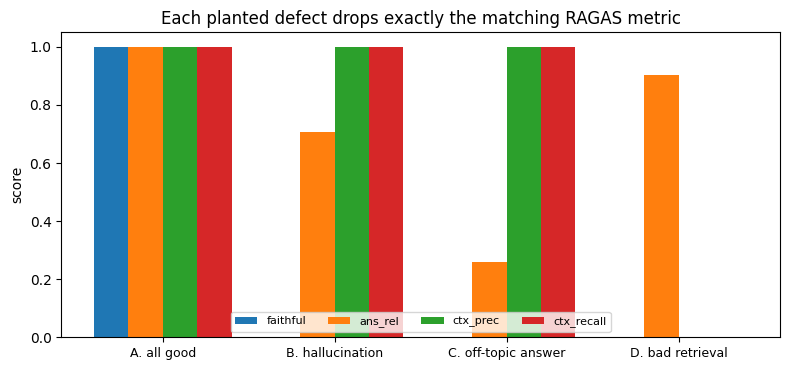

In [5]:
import matplotlib.pyplot as plt
import numpy as np
data = df[cols].rename(columns=short).values
fig, ax = plt.subplots(figsize=(8,3.8))
x = np.arange(len(samples)); w = 0.2
for i, c in enumerate(["faithful","ans_rel","ctx_prec","ctx_recall"]):
    ax.bar(x + (i-1.5)*w, data[:, i], w, label=c)
ax.set_xticks(x); ax.set_xticklabels(list(samples.keys()), fontsize=9)
ax.set_ylim(0,1.05); ax.set_ylabel("score"); ax.legend(fontsize=8, ncol=4, loc="lower center")
ax.set_title("Each planted defect drops exactly the matching RAGAS metric")
plt.tight_layout(); plt.show()

## 6. Beyond the core four

- **Reference-free metrics**: `Faithfulness` and context-precision-*without*-reference need no ground
  truth — usable on live production traffic.
- **Other RAGAS metrics**: answer correctness, semantic similarity, noise sensitivity, and
  **agentic/tool-use** metrics for agent pipelines.
- **Synthetic test-set generation**: RAGAS can *generate* a labeled Q/A/context test set from your
  own documents, so you don't have to hand-write one.
- **Alternatives**: DeepEval (pytest-style), TruLens (RAG Triad), promptfoo — same ideas, different ergonomics.

**Practical loop:** build a small golden set → measure the four metrics → change one thing
(chunking, `k`, reranker, prompt) → re-measure → keep changes that move the metrics.

## 7. Summary

- RAG fails in two places; RAGAS measures **retrieval** (context precision/recall) and
  **generation** (faithfulness, answer relevancy) **separately**.
- We proved each metric isolates its own failure mode on planted examples.
- Faithfulness is your **hallucination detector**; answer relevancy catches evasive answers;
  context precision/recall diagnose the retriever.

### Next — Notebook 10: the capstone
We assemble **everything** — ingest → chunk → embed → index → hybrid retrieve → rerank →
generate a cited answer — and use **these RAGAS metrics** to prove each stage (better chunking,
hybrid vs single, reranking) actually improves the end-to-end system.